## 1. 데이터 로드 및 전처리

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import os

os.makedirs("../results/images", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [58]:
benign_path = "../data/Benign/stateless_features-benign_1.pcap.csv"
attack_path = "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_text.pcap.csv"

benign = pd.read_csv(benign_path)
attack = pd.read_csv(attack_path)

print("정상 데이터:", benign.shape)
print("공격 데이터:", attack.shape)

정상 데이터: (132499, 15)
공격 데이터: (71102, 15)


In [59]:
benign_ml = benign.copy()
attack_ml = attack.copy()

benign_ml["label"] = 0
attack_ml["label"] = 1

ml_df = pd.concat(
    [benign_ml, attack_ml],
    ignore_index=True
)

print("통합 데이터 크기:", ml_df.shape)

print("\nLabel 분포:")
print(ml_df["label"].value_counts())

통합 데이터 크기: (203601, 16)

Label 분포:
label
0    132499
1     71102
Name: count, dtype: int64


## 2. Feature 선정 및 Train/Test Split

In [60]:
features = [
    "FQDN_count",
    "subdomain_length",
    "numeric",
    "entropy",
    "special",
    "labels",
    "labels_max",
    "labels_average",
    "len"
]

X = ml_df[features]
y = ml_df["label"]

print("X 크기:", X.shape)
print("y 크기:", y.shape)

print("\n결측치:")
print(X.isnull().sum())

X 크기: (203601, 9)
y 크기: (203601,)

결측치:
FQDN_count          0
subdomain_length    0
numeric             0
entropy             0
special             0
labels              0
labels_max          0
labels_average      0
len                 0
dtype: int64


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\n학습 데이터 Label 분포:")
print(y_train.value_counts())

print("\n테스트 데이터 Label 분포:")
print(y_test.value_counts())

X_train: (162880, 9)
X_test : (40721, 9)
y_train: (162880,)
y_test : (40721,)

학습 데이터 Label 분포:
label
0    105999
1     56881
Name: count, dtype: int64

테스트 데이터 Label 분포:
label
0    26500
1    14221
Name: count, dtype: int64


## 3. RandomForest

In [62]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("RandomForest 학습 완료")

RandomForest 학습 완료


In [63]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7162643353552222
Precision: 0.5519134192393039
Recall   : 0.9969059841080092
F1-score : 0.7104841134609602

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     26500
           1       0.55      1.00      0.71     14221

    accuracy                           0.72     40721
   macro avg       0.77      0.78      0.72     40721
weighted avg       0.84      0.72      0.72     40721



## 4. XGBoost

In [64]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost 학습 완료")

XGBoost 학습 완료


In [65]:
y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.7163134500626213
Precision: 0.5519402171797766
Recall   : 0.9971872582800084
F1-score : 0.7105777421456131

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     26500
           1       0.55      1.00      0.71     14221

    accuracy                           0.72     40721
   macro avg       0.77      0.78      0.72     40721
weighted avg       0.84      0.72      0.72     40721



## 5. LightGBM

In [66]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

print("LightGBM 학습 완료")

[LightGBM] [Info] Number of positive: 56881, number of negative: 105999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000765 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 448
[LightGBM] [Info] Number of data points in the train set: 162880, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.349220 -> initscore=-0.622468
[LightGBM] [Info] Start training from score -0.622468
LightGBM 학습 완료


In [67]:
y_pred_lgbm = lgbm_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall   :", recall_score(y_test, y_pred_lgbm))
print("F1-score :", f1_score(y_test, y_pred_lgbm))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lgbm))

Accuracy : 0.7162397780015226
Precision: 0.5518919339769542
Recall   : 0.9969059841080092
F1-score : 0.7104663108572001

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     26500
           1       0.55      1.00      0.71     14221

    accuracy                           0.72     40721
   macro avg       0.77      0.78      0.72     40721
weighted avg       0.84      0.72      0.72     40721



## 6. Logistic Regression

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.7143979764740551
Precision: 0.5509577941234315
Recall   : 0.9849518317980451
F1-score : 0.7066390878821511

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.57      0.72     26500
           1       0.55      0.98      0.71     14221

    accuracy                           0.71     40721
   macro avg       0.77      0.78      0.71     40721
weighted avg       0.83      0.71      0.72     40721



## 7. HistGradientBoosting

In [69]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    random_state=42
)

hgb_model.fit(X_train, y_train)

y_pred_hgb = hgb_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_hgb))
print("Precision:", precision_score(y_test, y_pred_hgb))
print("Recall   :", recall_score(y_test, y_pred_hgb))
print("F1-score :", f1_score(y_test, y_pred_hgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_hgb))

Accuracy : 0.7162888927089217
Precision: 0.5519308626596076
Recall   : 0.9969763026510091
F1-score : 0.7105164248665714

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     26500
           1       0.55      1.00      0.71     14221

    accuracy                           0.72     40721
   macro avg       0.77      0.78      0.72     40721
weighted avg       0.84      0.72      0.72     40721



## 8. IsolationForest

In [70]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train)

print("IsolationForest 학습 완료")

IsolationForest 학습 완료


In [71]:
iso_pred_raw = iso_model.predict(X_test)

# IsolationForest 결과:
#  1  = 정상
# -1  = 이상치
#
# 우리 Label:
#  0 = 정상
#  1 = 공격
#
# 따라서 변환
y_pred_iso = np.where(iso_pred_raw == -1, 1, 0)

print("Accuracy :", accuracy_score(y_test, y_pred_iso))
print("Precision:", precision_score(y_test, y_pred_iso))
print("Recall   :", recall_score(y_test, y_pred_iso))
print("F1-score :", f1_score(y_test, y_pred_iso))

print("\nClassification Report")
print(classification_report(y_test, y_pred_iso))

Accuracy : 0.5353994253579234
Precision: 0.20841608738828202
Recall   : 0.1180648336966458
F1-score : 0.15073842977061544

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.76      0.68     26500
           1       0.21      0.12      0.15     14221

    accuracy                           0.54     40721
   macro avg       0.41      0.44      0.42     40721
weighted avg       0.47      0.54      0.50     40721



## 9. DNN

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

Train shape: (162880, 9)
Test shape : (40721, 9)


In [73]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dnn_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

dnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dnn_model.summary()

/Users/thisiszero1/Desktop/dns-malicious-detection/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = dnn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step - accuracy: 0.7118 - loss: 0.4631 - val_accuracy: 0.7182 - val_loss: 0.4423
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - accuracy: 0.7180 - loss: 0.4418 - val_accuracy: 0.7181 - val_loss: 0.4384
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - accuracy: 0.7183 - loss: 0.4382 - val_accuracy: 0.7179 - val_loss: 0.4374
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.7191 - loss: 0.4369 - val_accuracy: 0.7182 - val_loss: 0.4367
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - accuracy: 0.7191 - loss: 0.4357 - val_accuracy: 0.7185 - val_loss: 0.4360
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.7198 - loss: 0.4349 - val_accuracy: 0.7184 - val_loss: 0.4357
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.7197 - loss: 0.4346 - val_accuracy: 0.7184 - val_loss: 0.4359
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.7200 - loss: 0.4343 - 

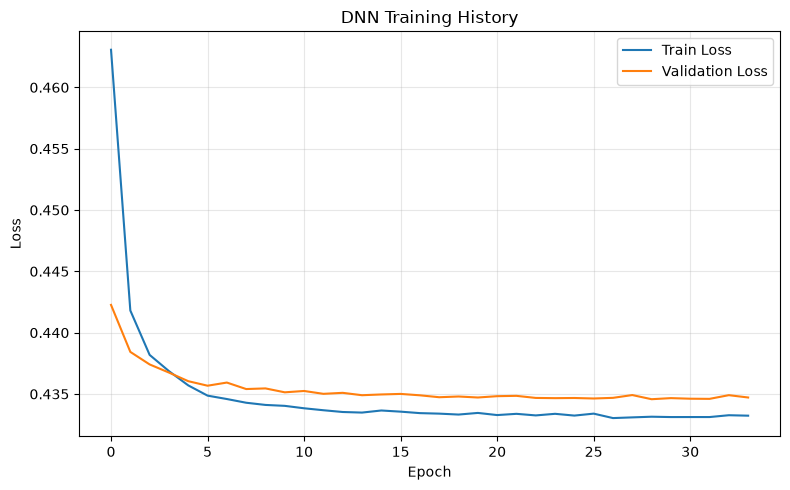

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DNN Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/images/dnn_training_history.png", dpi=300, bbox_inches="tight")
plt.show()


In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# 확률 예측
y_prob_dnn = dnn_model.predict(X_test_scaled).ravel()

# 0.5 기준 이진 분류
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_dnn))
print("Precision:", precision_score(y_test, y_pred_dnn))
print("Recall   :", recall_score(y_test, y_pred_dnn))
print("F1-score :", f1_score(y_test, y_pred_dnn))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dnn))

1273/1273 ━━━━━━━━━━━━━━━━━━━━ 0s 185us/step
Accuracy : 0.7154293853294369
Precision: 0.5510686993289111
Recall   : 0.9989452218550031
F1-score : 0.7103

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.56      0.72     26500
           1       0.55      1.00      0.71     14221

    accuracy                           0.72     40721
   macro avg       0.78      0.78      0.72     40721
weighted avg       0.84      0.72      0.72     40721



## 10. Model Comparison

In [77]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# 확률값 준비
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_prob_hgb = hgb_model.predict_proba(X_test)[:, 1]

# DNN은 이미 y_prob_dnn 존재
# IsolationForest는 확률 기반 ROC/PR 비교에서 제외

models = [
    ("RandomForest", y_pred_rf, y_prob_rf),
    ("XGBoost", y_pred_xgb, y_prob_xgb),
    ("LightGBM", y_pred_lgbm, y_prob_lgbm),
    ("LogisticRegression", y_pred_lr, y_prob_lr),
    ("HistGradientBoosting", y_pred_hgb, y_prob_hgb),
    ("DNN", y_pred_dnn, y_prob_dnn),
]

rows = []

for name, y_pred, y_prob in models:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fpr = fp / (fp + tn)

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "FPR": fpr,
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

# IsolationForest 별도 추가
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_iso).ravel()

rows.append({
    "Model": "IsolationForest",
    "Accuracy": accuracy_score(y_test, y_pred_iso),
    "Precision": precision_score(y_test, y_pred_iso),
    "Recall": recall_score(y_test, y_pred_iso),
    "F1-score": f1_score(y_test, y_pred_iso),
    "FPR": fp / (fp + tn),
    "ROC-AUC": None,
    "PR-AUC": None
})

model_comparison = pd.DataFrame(rows)

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,FPR,ROC-AUC,PR-AUC
0,RandomForest,0.7163,0.5519,0.9969,0.7105,0.4343,0.7824,0.5549
1,XGBoost,0.7163,0.5519,0.9972,0.7106,0.4344,0.7825,0.5553
2,LightGBM,0.7162,0.5519,0.9969,0.7105,0.4344,0.7826,0.5554
3,LogisticRegression,0.7144,0.5510,0.9850,0.7066,0.4308,0.7789,0.5479
4,HistGradientBoosting,0.7163,0.5519,0.9970,0.7105,0.4343,0.7827,0.5554
5,DNN,0.7154,0.5511,0.9989,0.7103,0.4367,0.7828,0.5540
6,IsolationForest,0.5354,0.2084,0.1181,0.1507,0.2406,NaN,NaN


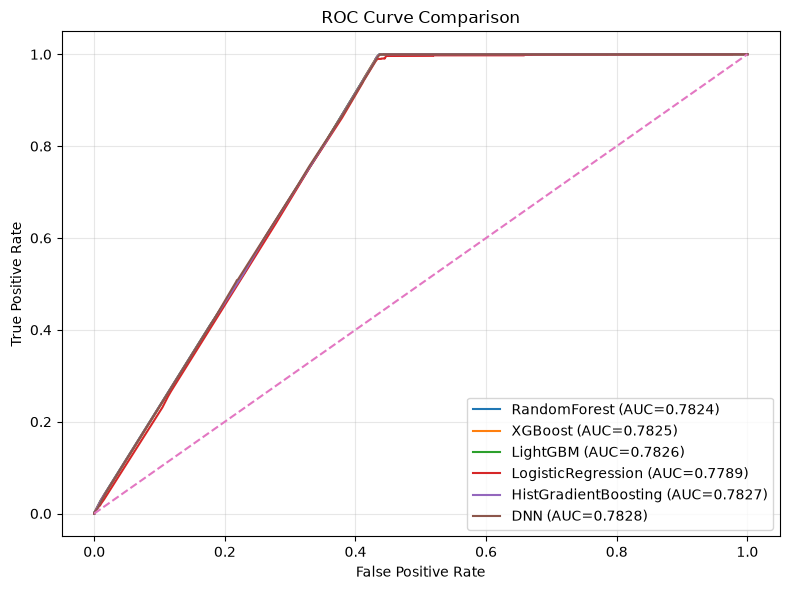

In [78]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

roc_models = [
    ("RandomForest", y_prob_rf),
    ("XGBoost", y_prob_xgb),
    ("LightGBM", y_prob_lgbm),
    ("LogisticRegression", y_prob_lr),
    ("HistGradientBoosting", y_prob_hgb),
    ("DNN", y_prob_dnn),
]

plt.figure(figsize=(8, 6))

for name, y_prob in roc_models:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.4f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/images/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


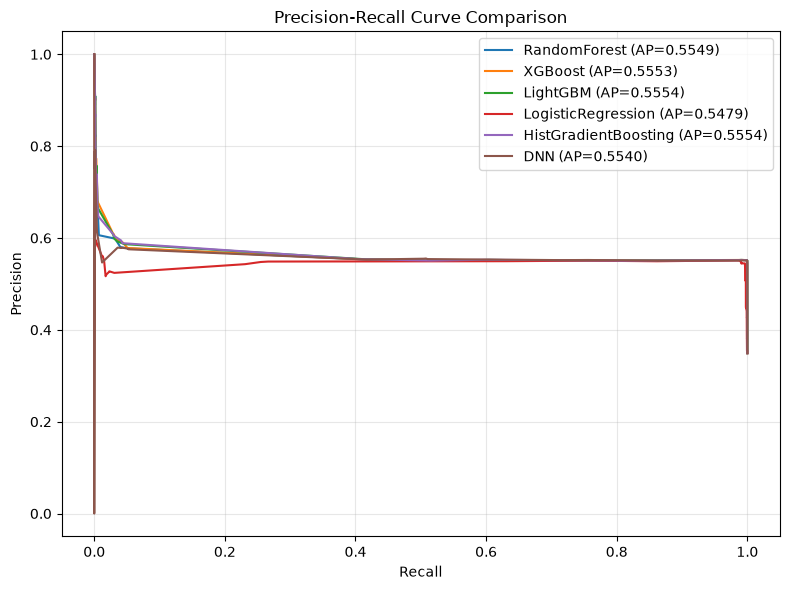

In [79]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

pr_models = [
    ("RandomForest", y_prob_rf),
    ("XGBoost", y_prob_xgb),
    ("LightGBM", y_prob_lgbm),
    ("LogisticRegression", y_prob_lr),
    ("HistGradientBoosting", y_prob_hgb),
    ("DNN", y_prob_dnn),
]

plt.figure(figsize=(8, 6))

for name, y_prob in pr_models:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={pr_auc:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/images/pr_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Model Comparison Interpretation

- RandomForest, XGBoost, LightGBM, HistGradientBoosting, DNN은 Accuracy와 F1-score에서 매우 유사한 결과를 보였다.
- DNN은 공격 Recall이 약 0.999로 가장 높고 ROC-AUC / PR-AUC도 가장 높은 수준이었지만, FPR 역시 약 0.44 수준으로 높아 정상 DNS 오탐 문제가 남아 있다.
- Logistic Regression은 성능이 소폭 낮았지만 지도학습 모델 중 FPR이 상대적으로 낮았다.
- IsolationForest는 현재 혼합 학습 데이터 기반 baseline 설정에서는 지도학습 모델보다 성능이 크게 낮았다.
- 여러 모델의 성능이 거의 비슷하다는 점은 현재 병목이 단순한 모델 선택보다 Feature 구성, 데이터 범위, 임계값 설정 및 False Positive 문제와 더 관련될 가능성을 시사한다.


## 11. INT8 Quantization

In [80]:
import tensorflow as tf
import numpy as np
import os

# INT8 양자화를 위한 Representative Dataset
def representative_dataset():
    sample_count = min(1000, len(X_train_scaled))

    for i in range(sample_count):
        sample = X_train_scaled[i:i+1].astype(np.float32)
        yield [sample]


# Keras DNN → TFLite INT8 변환
converter = tf.lite.TFLiteConverter.from_keras_model(dnn_model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

dnn_int8_model = converter.convert()


# 저장
os.makedirs("../results", exist_ok=True)

int8_path = "../results/dnn_int8.tflite"

with open(int8_path, "wb") as f:
    f.write(dnn_int8_model)


# 모델 크기 확인
int8_size_kb = os.path.getsize(int8_path) / 1024

print("INT8 conversion completed")
print(f"INT8 model size: {int8_size_kb:.2f} KB")
print("Saved:", int8_path)

INFO:tensorflow:Assets written to: /var/folders/b9/6_gb8dy55x94t971s47_rxfc0000gn/T/tmp52sv_q_u/assets


INFO:tensorflow:Assets written to: /var/folders/b9/6_gb8dy55x94t971s47_rxfc0000gn/T/tmp52sv_q_u/assets


Saved artifact at '/var/folders/b9/6_gb8dy55x94t971s47_rxfc0000gn/T/tmp52sv_q_u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9), dtype=tf.float32, name='keras_tensor_21')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  13001260496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13006639696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12956277008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12956280080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12956272016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12956279120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12956276816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12956277584: TensorSpec(shape=(), dtype=tf.resource, name=None)
INT8 conversion completed
INT8 model size: 9.17 KB
Saved: ../results/dnn_int8.tflite


/Users/thisiszero1/Desktop/dns-malicious-detection/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1791349821.433432 13628457 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791349821.433441 13628457 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1791349821.433512 13628457 reader.cc:83] Reading SavedModel from: /var/folders/b9/6_gb8dy55x94t971s47_rxfc0000gn/T/tmp52sv_q_u
I0000 00:00:1791349821.433740 13628457 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1791349821.433742 13628457 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/b9/6_gb8dy55x94t971s47_rxfc0000gn/T/tmp52sv_q_u
I0000 00:00:1791349821.436024 13628457 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1791349821.449699 13628457 loader.cc:220] Running initialization op 

In [81]:
import tensorflow as tf
import numpy as np

interpreter = tf.lite.Interpreter(
    model_path="../results/dnn_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

print("Input quantization :", input_scale, input_zero_point)
print("Output quantization:", output_scale, output_zero_point)

Input quantization : 0.0387900173664093 -40
Output quantization: 0.00390625 -128


/Users/thisiszero1/Desktop/dns-malicious-detection/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_prob_int8 = []

for i in range(len(X_test_scaled)):
    sample = X_test_scaled[i:i+1]

    # float32 -> int8 quantization
    sample_int8 = np.round(
        sample / input_scale + input_zero_point
    ).astype(np.int8)

    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    interpreter.invoke()

    output_int8 = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # int8 -> float32 dequantization
    output_float = (
        output_int8.astype(np.float32) - output_zero_point
    ) * output_scale

    y_prob_int8.append(output_float[0][0])

y_prob_int8 = np.array(y_prob_int8)

y_pred_int8 = (y_prob_int8 >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_int8))
print("Precision:", precision_score(y_test, y_pred_int8))
print("Recall   :", recall_score(y_test, y_pred_int8))
print("F1-score :", f1_score(y_test, y_pred_int8))

print("\nClassification Report")
print(classification_report(y_test, y_pred_int8))

Accuracy : 0.7154293853294369
Precision: 0.5510686993289111
Recall   : 0.9989452218550031
F1-score : 0.7103

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.56      0.72     26500
           1       0.55      1.00      0.71     14221

    accuracy                           0.72     40721
   macro avg       0.78      0.78      0.72     40721
weighted avg       0.84      0.72      0.72     40721



In [83]:
# FP32 DNN vs INT8 DNN 성능 비교
dnn_int8_comparison = pd.DataFrame([
    {
        "Model": "DNN FP32",
        "Accuracy": accuracy_score(y_test, y_pred_dnn),
        "Precision": precision_score(y_test, y_pred_dnn),
        "Recall": recall_score(y_test, y_pred_dnn),
        "F1-score": f1_score(y_test, y_pred_dnn)
    },
    {
        "Model": "DNN INT8",
        "Accuracy": accuracy_score(y_test, y_pred_int8),
        "Precision": precision_score(y_test, y_pred_int8),
        "Recall": recall_score(y_test, y_pred_int8),
        "F1-score": f1_score(y_test, y_pred_int8)
    }
])

dnn_int8_comparison.round(4)


,Model,Accuracy,Precision,Recall,F1-score
0,DNN FP32,0.7154,0.5511,0.9989,0.7103
1,DNN INT8,0.7154,0.5511,0.9989,0.7103


In [84]:
import time
import numpy as np

test_samples = X_test_scaled[:1000]

# -----------------------------
# FP32 single-sample latency
# -----------------------------
fp32_times = []

for i in range(len(test_samples)):
    sample = test_samples[i:i+1]

    start = time.perf_counter()

    _ = dnn_model(sample, training=False).numpy()

    end = time.perf_counter()

    fp32_times.append((end - start) * 1000)


# -----------------------------
# INT8 single-sample latency
# -----------------------------
int8_times = []

for i in range(len(test_samples)):
    sample = test_samples[i:i+1]

    sample_int8 = np.round(
        sample / input_scale + input_zero_point
    ).astype(np.int8)

    start = time.perf_counter()

    interpreter.set_tensor(
        input_details[0]["index"],
        sample_int8
    )

    interpreter.invoke()

    _ = interpreter.get_tensor(
        output_details[0]["index"]
    )

    end = time.perf_counter()

    int8_times.append((end - start) * 1000)


print(f"FP32 avg latency : {np.mean(fp32_times):.6f} ms/sample")
print(f"INT8 avg latency : {np.mean(int8_times):.6f} ms/sample")

print()
print(f"FP32 median latency : {np.median(fp32_times):.6f} ms/sample")
print(f"INT8 median latency : {np.median(int8_times):.6f} ms/sample")

FP32 avg latency : 1.478984 ms/sample
INT8 avg latency : 0.002115 ms/sample

FP32 median latency : 1.380625 ms/sample
INT8 median latency : 0.001917 ms/sample


### INT8 Quantization Interpretation

- DNN을 TensorFlow Lite INT8로 양자화한 뒤에도 Accuracy, Recall, F1-score가 FP32 모델과 거의 동일하게 유지되었다.
- INT8 TFLite 파일 크기는 약 **9.16 KB**로 확인되어 매우 작은 배포용 모델을 구성할 수 있었다.
- 단일 샘플 CPU benchmark에서는 INT8 TFLite가 FP32 Keras보다 훨씬 낮은 latency를 보였다.
- 다만 FP32는 TensorFlow/Keras eager runtime, INT8은 TFLite/XNNPACK runtime을 사용하므로 추론 시간 차이를 순수한 양자화 효과로만 해석해서는 안 된다.
- 따라서 본 결과는 성능 저하 없이 경량 배포가 가능하다는 점과 Edge / On-Device 환경 적용 가능성을 확인한 결과로 해석한다.


## 12. Confusion Matrix


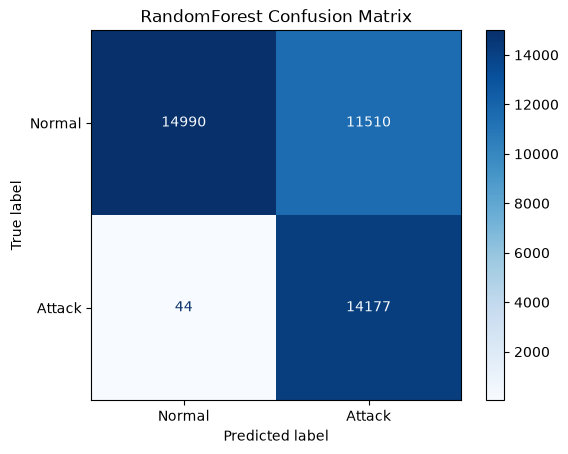

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("RandomForest Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_rf.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

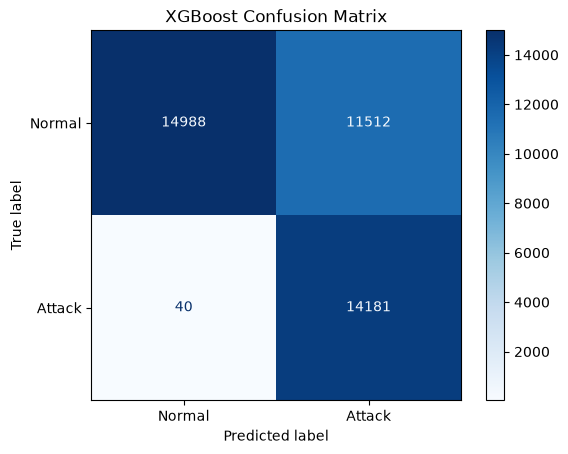

In [86]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_xgb.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

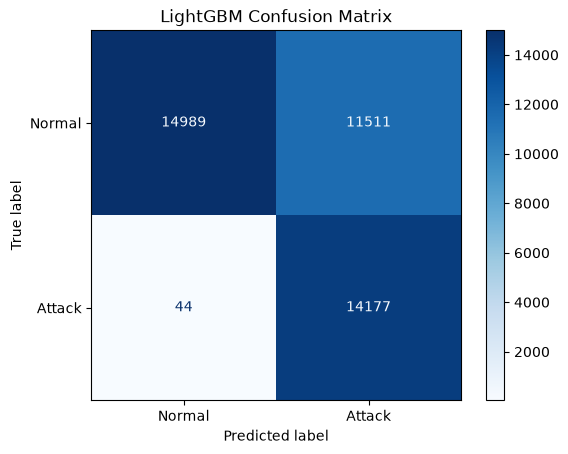

In [87]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("LightGBM Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_lgbm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

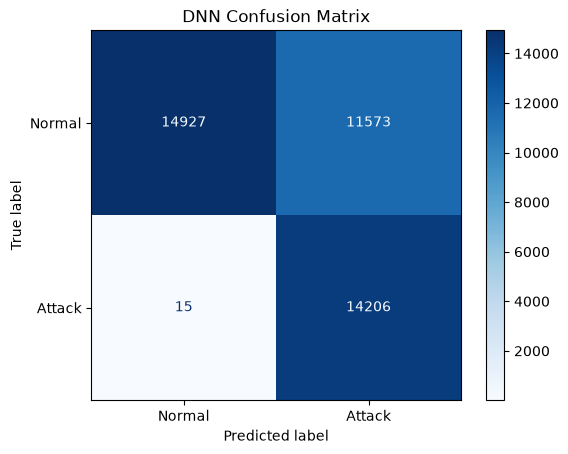

In [88]:
cm_dnn = confusion_matrix(y_test, y_pred_dnn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dnn,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("DNN Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_dnn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


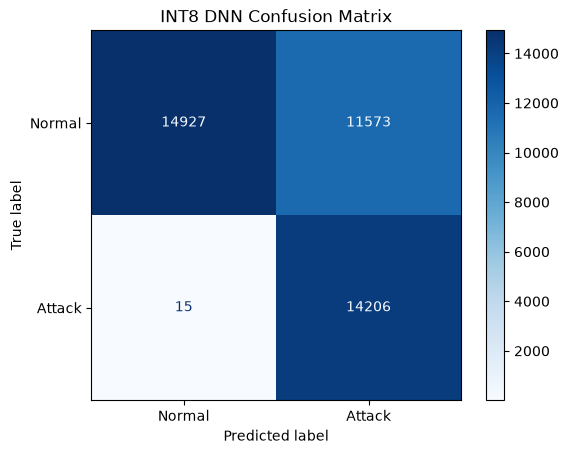

In [89]:
cm_int8 = confusion_matrix(y_test, y_pred_int8)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_int8,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("INT8 DNN Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_int8.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


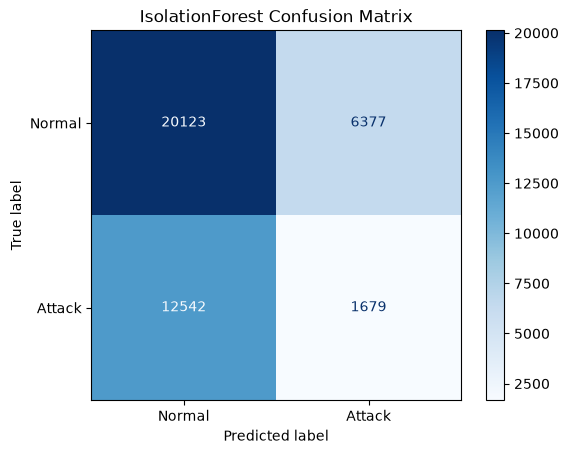

In [90]:
cm_iso = confusion_matrix(y_test, y_pred_iso)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_iso,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("IsolationForest Confusion Matrix")
plt.savefig(
    "../results/images/confusion_matrix_iso.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 13. Feature Importance


In [91]:
feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf

,Feature,Importance
0,FQDN_count,0.324400
1,subdomain_length,0.236994
4,special,0.214456
5,labels,0.097209
2,numeric,0.057963
7,labels_average,0.033817
8,len,0.016252
3,entropy,0.011782
6,labels_max,0.007128


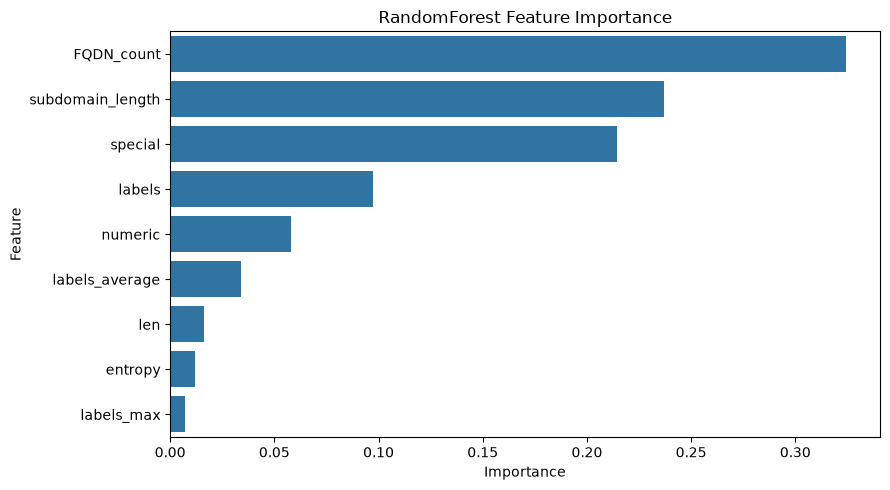

In [92]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=feature_importance_rf,
    x="Importance",
    y="Feature"
)

ax.set_title("RandomForest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(
    "../results/images/feature_importance_rf.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 14. 최종 해석

### 모델 실험 결과
- RandomForest, XGBoost, LightGBM, Logistic Regression, HistGradientBoosting, DNN 및 IsolationForest를 비교하였다.
- 지도학습 모델들은 Accuracy 약 0.71, F1-score 약 0.71 수준으로 매우 유사한 결과를 보였다.
- 특히 공격 Recall은 대부분 약 0.99로 매우 높아 공격 샘플을 거의 놓치지 않았지만, Precision은 약 0.55 수준에 머물렀다.
- FPR 또한 약 0.43~0.44 수준으로 높아 정상 DNS를 공격으로 잘못 판단하는 False Positive가 핵심 문제로 확인되었다.
- DNN은 가장 높은 수준의 Recall, ROC-AUC, PR-AUC를 보였지만 오탐 문제 자체는 해결하지 못했다.

### Feature 해석
- RandomForest Feature Importance에서는 `FQDN_count`, `subdomain_length`, `special`이 상대적으로 높은 중요도를 보였다.
- EDA의 Mann–Whitney U / Kruskal–Wallis 통계분석에서 차이가 크게 나타난 주요 Feature와 모델 중요도가 대체로 일관된 방향을 보였다.
- 반면 `entropy`, `labels_max`는 통계적 p-value는 매우 작지만 effect size가 작아, p-value만으로 Feature 중요도를 판단해서는 안 됨을 확인하였다.

### DNN 및 INT8 경량화
- 9개 입력 Feature를 사용하는 소형 DNN을 구성하고 EarlyStopping 기반으로 학습하였다.
- DNN의 공격 Recall은 약 0.999 수준으로 매우 높게 나타났다.
- TensorFlow Lite INT8 양자화 후에도 Accuracy, Recall, F1-score가 FP32와 거의 동일하게 유지되었다.
- INT8 TFLite 모델 파일은 약 9.16 KB로 생성되어 Edge / On-Device 환경에서 재사용 가능한 경량 모델 형태로 확장 가능함을 확인하였다.
- CPU latency 측정에서는 INT8 TFLite가 낮은 추론 시간을 보였지만, Keras와 TFLite의 runtime 차이가 있으므로 이를 순수한 양자화 속도 향상 배수로 해석하지 않는다.

### 한계 및 다음 단계
- 현재 학습은 대표 정상 데이터와 Heavy Text 공격 데이터를 중심으로 수행했기 때문에 전체 DNS 공격 유형의 일반 성능으로 해석할 수 없다.
- Text / Audio / Image / Video / Compressed / EXE 전체 Attack Type을 통합한 모델 검증이 필요하다.
- Stateful Feature(`ttl_mean`, `ttl_variance`, `unique_ttl_count`)와 Stateless Feature를 통합한 추가 실험이 필요하다.
- 현재 가장 큰 실용적 문제는 False Positive이므로 threshold tuning, class weighting, calibration 및 Feature 재구성을 통해 FPR 개선이 필요하다.
- IsolationForest는 정상 데이터만을 이용한 재학습 방식으로 다시 실험해야 anomaly detection baseline으로 더 타당한 비교가 가능하다.


In [93]:
model_comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)

feature_importance_rf.to_csv(
    "../results/feature_importance.csv",
    index=False
)

dnn_int8_comparison.to_csv(
    "../results/dnn_int8_comparison.csv",
    index=False
)

print("결과 CSV 저장 완료")


결과 CSV 저장 완료
